In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xtrack as xt
import xcoll as xc
import sys
import json
import gzip
import matplotlib.patches as mpatches

# helper_dir = Path("/eos/user/l/lpauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions")
helper_dir = Path("/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions")
sys.path.insert(0, str(helper_dir)) 

In [3]:
def load_data(line_types, chromas, planes, result_path=None, verbose=True):
    if result_path is None:
        result_path = study_path.parents[2] / 'results'
    result_path = Path(result_path).resolve()

    data = {}
    for lt in line_types:
        data[lt] = {}
        for chroma in chromas:
            data[lt][chroma] = {}
            for plane in planes:
                data[lt][chroma][plane] = {}
                file_path = result_path / f'death_turns_{lt}_{chroma}_{plane}.json.gz'
                if not file_path.exists():
                    if verbose:
                        print(f'File {file_path} does not exist, skipping')
                    continue
                if verbose:
                    print(f'Loading data from {file_path}')
                with gzip.open(file_path, 'rt', encoding='utf-8') as f:
                    death_turns_data = json.load(f)
                turns, counts = np.unique(death_turns_data['at_turn'], return_counts=True)
                data[lt][chroma][plane] = {'turns' : turns, 'counts' : counts}
    return data

def df_to_delta(df):
    slip_factor = 0.0017935055033301713
    f = 200_000_000
    return 1/slip_factor * df/f

def get_normalised_intensity_loss(data, line_types, chromas, planes, total_particles, sweep_per_turn=1.0):
    normalised_intensity_loss = {}
    for lt in line_types:
        normalised_intensity_loss[lt] = {}
        for chroma in chromas:
            normalised_intensity_loss[lt][chroma] = {}
            for plane in planes:
                turns = data[lt][chroma][plane]['turns']
                counts = data[lt][chroma][plane]['counts']

                turns = np.concatenate(([0], turns))
                counts = np.concatenate(([0], counts))

                deltas = df_to_delta(turns * sweep_per_turn)
                if plane == 'DPneg':
                    deltas = -deltas
                
                normalised_intensity_loss[lt][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / total_particles}
    return normalised_intensity_loss

In [5]:
def make_line(Qx_range, Qy_range, p, q, r, ax, ls='--', color='yellowgreen'):
    if p==0:
        Qy = r/q
        ax.hlines(Qy, Qx_range[0], Qx_range[1], color=color, ls=ls)
    elif q == 0:
        Qx = r/p
        ax.vlines(Qx, Qy_range[0], Qy_range[1], color=color, ls=ls)
    
    else:
        Qx = np.linspace(Qx_range[0], Qx_range[1])
        Qy = (r-p*Qx)/q
        ax.plot(Qx, Qy, color=color, ls=ls)

In [6]:
from __future__ import annotations
from itertools import product
from typing import Callable, Iterable, Iterator, Tuple


def triples_abs_sum(n: int) -> Iterator[Tuple[int, int, int]]:
    """
    Yield all integer triples (p, q, r) such that |p| + |q| + |r| = n.

    Order is deterministic:
      - iterate nonnegative magnitudes (ap, aq, ar) with ap+aq+ar=n
      - then expand to signed values (skipping duplicate signs for zeros)
    """
    if n < 0:
        raise ValueError("n must be >= 0")

    for ap in range(n + 1):
        for aq in range(n - ap + 1):
            ar = n - ap - aq

            Ps = (0,) if ap == 0 else (-ap, ap)
            Qs = (0,) if aq == 0 else (-aq, aq)
            Rs = (0,) if ar == 0 else (-ar, ar)

            yield from product(Ps, Qs, Rs)


def filter_triples(
    triples: Iterable[Tuple[int, int, int]],
    condition: Callable[[int, int, int], bool],
) -> Iterator[Tuple[int, int, int]]:
    """
    Generic filter for (p,q,r) triples.

    condition(p,q,r) must return True to keep the triple.
    """
    for p, q, r in triples:
        if condition(p, q, r):
            yield (p, q, r)

# Example
if __name__ == "__main__":
    n = 3
    triples = triples_abs_sum(n)

    filtered = filter_triples(triples, lambda p, q, r: not (p == 0 and q == 0))

    print(list(filtered))


[(0, -1, -2), (0, -1, 2), (0, 1, -2), (0, 1, 2), (0, -2, -1), (0, -2, 1), (0, 2, -1), (0, 2, 1), (0, -3, 0), (0, 3, 0), (-1, 0, -2), (-1, 0, 2), (1, 0, -2), (1, 0, 2), (-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1), (1, -1, -1), (1, -1, 1), (1, 1, -1), (1, 1, 1), (-1, -2, 0), (-1, 2, 0), (1, -2, 0), (1, 2, 0), (-2, 0, -1), (-2, 0, 1), (2, 0, -1), (2, 0, 1), (-2, -1, 0), (-2, 1, 0), (2, -1, 0), (2, 1, 0), (-3, 0, 0), (3, 0, 0)]


In [7]:
n = 3
triples = triples_abs_sum(n)

filtered = list(filter_triples(triples_abs_sum(3), lambda p,q,r: not (p==0 and q==0)))

print(list(filtered))
print(list(filtered))
first_order_res = list(filter_triples(triples_abs_sum(1), lambda p,q,r: not (p==0 and q==0)))
second_order_res = list(filter_triples(triples_abs_sum(2), lambda p,q,r: not (p==0 and q==0)))
third_order_res = list(filter_triples(triples_abs_sum(3), lambda p,q,r: not (p==0 and q==0)))

[(0, -1, -2), (0, -1, 2), (0, 1, -2), (0, 1, 2), (0, -2, -1), (0, -2, 1), (0, 2, -1), (0, 2, 1), (0, -3, 0), (0, 3, 0), (-1, 0, -2), (-1, 0, 2), (1, 0, -2), (1, 0, 2), (-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1), (1, -1, -1), (1, -1, 1), (1, 1, -1), (1, 1, 1), (-1, -2, 0), (-1, 2, 0), (1, -2, 0), (1, 2, 0), (-2, 0, -1), (-2, 0, 1), (2, 0, -1), (2, 0, 1), (-2, -1, 0), (-2, 1, 0), (2, -1, 0), (2, 1, 0), (-3, 0, 0), (3, 0, 0)]
[(0, -1, -2), (0, -1, 2), (0, 1, -2), (0, 1, 2), (0, -2, -1), (0, -2, 1), (0, 2, -1), (0, 2, 1), (0, -3, 0), (0, 3, 0), (-1, 0, -2), (-1, 0, 2), (1, 0, -2), (1, 0, 2), (-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1), (1, -1, -1), (1, -1, 1), (1, 1, -1), (1, 1, 1), (-1, -2, 0), (-1, 2, 0), (1, -2, 0), (1, 2, 0), (-2, 0, -1), (-2, 0, 1), (2, 0, -1), (2, 0, 1), (-2, -1, 0), (-2, 1, 0), (2, -1, 0), (2, 1, 0), (-3, 0, 0), (3, 0, 0)]


In [8]:
['f3000', 'f1200', 'f1020', 'f0120', 'f0111']
third_order_resonances = [(3,0, 0), (-1, 0, 2), (1, 2, 0), (-1, 2, 0), (-1, 0, 2)]

In [13]:
from itertools import product


def resonance_dict(max_order: int, exclude_mn_zero: bool = True):
    """
    Generate resonance triplets (m,n,p) grouped by order = |m|+|n|+|p|.

    Returns
    -------
    d : dict[int, list[tuple[int,int,int]]]
        Keys are orders, values are lists of (m,n,p).

    Parameters
    ----------
    max_order : int
        Maximum order to generate.
    exclude_mn_zero : bool
        If True, excludes (m,n,p) where m=0 and n=0 (meaning no resonance line).
    """
    d = {}

    for order in range(1, max_order + 1):
        triples = []

        for m in range(-order, order + 1):
            for n in range(-order, order + 1):
                for p in range(-order, order + 1):

                    if abs(m) + abs(n) + abs(p) != order:
                        continue

                    if exclude_mn_zero and (m == 0 and n == 0):
                        continue

                    triples.append((m, n, p))

        d[order] = triples

    return d

from __future__ import annotations
from math import gcd
from functools import reduce
from typing import Iterable, Iterator, Tuple


def is_reducible(m: int, n: int, p: int) -> bool:
    """
    True if (m,n,p) can be divided by an integer g>1, i.e. it represents the same line
    as a lower-order triplet.
    """
    g = reduce(gcd, (abs(m), abs(n), abs(p)))
    return g > 1


def primitive_triplets(triplets: Iterable[Tuple[int, int, int]]) -> Iterator[Tuple[int, int, int]]:
    """
    Keep only *primitive* (irreducible) triplets: gcd(|m|,|n|,|p|)=1.
    """
    for m, n, p in triplets:
        if not is_reducible(m, n, p):
            yield (m, n, p)

# Example usage
if __name__ == "__main__":
    d_full = resonance_dict(4)
    d = {k: list(primitive_triplets(v)) for k, v in d_full.items()}
    for k, v in d.items():
        print(f"Order {k}: {len(v)} resonances")
        print(v[:10])


Order 1: 4 resonances
[(-1, 0, 0), (0, -1, 0), (0, 1, 0), (1, 0, 0)]
Order 2: 12 resonances
[(-1, -1, 0), (-1, 0, -1), (-1, 0, 1), (-1, 1, 0), (0, -1, -1), (0, -1, 1), (0, 1, -1), (0, 1, 1), (1, -1, 0), (1, 0, -1)]
Order 3: 32 resonances
[(-2, -1, 0), (-2, 0, -1), (-2, 0, 1), (-2, 1, 0), (-1, -2, 0), (-1, -1, -1), (-1, -1, 1), (-1, 0, -2), (-1, 0, 2), (-1, 1, -1)]
Order 4: 48 resonances
[(-3, -1, 0), (-3, 0, -1), (-3, 0, 1), (-3, 1, 0), (-2, -1, -1), (-2, -1, 1), (-2, 1, -1), (-2, 1, 1), (-1, -3, 0), (-1, -2, -1)]


In [14]:
def midplane_symmetry_filter(m, n, p):
    """
    Midplane symmetry rule: only resonances with even n survive.
    """
    return (n % 2) == 0

def superperiodicity_filter(m, n, p, S):
    """
    Superperiodicity rule: resonance harmonic p must be a multiple of S.
    """
    return (p % S) == 0

def resonance_allowed(m, n, p, S=None):
    """
    Combined resonance selection rule:
      - midplane symmetry (n even)
      - optional superperiodicity condition (p multiple of S)
    """
    if (n % 2) != 0:
        return False

    if S is not None and (p % S) != 0:
        return False

    return True

S = 6  # example: SPS superperiodicity
d = {
    order: [(m, n, p) for (m, n, p) in triples if resonance_allowed(m, n, p)]
    for order, triples in d.items()
}

# Find midpoints

In [16]:
import sys
helper_dir = Path("/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions")
sys.path.insert(0, str(helper_dir)) 

In [17]:
import midpoints_analysis as mpa

In [18]:
path_MD_data = Path('/Users/lisepauwels/sps_simulations/MD_data/20250616/')
path_study_results = Path("/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/IntensityScan2/study_results")
name_files = [p.name for p in path_study_results.iterdir()]

In [19]:
sweep_per_turn = 1.0
data_simulations = {'linear' : {}, 'errors': {}}
for name_file in name_files:
    with gzip.open(path_study_results / name_file, "rt") as f:
        study_results = json.load(f)

    line_type = name_file.split("_")[1]
    chroma = float(name_file.split("_")[2].split(".json")[0])
    print(line_type, chroma)
    if chroma not in data_simulations[line_type]:
        data_simulations[line_type][chroma] = {}
    
    for plane in list(study_results.keys()):
        assert abs(study_results[plane]['sweep_per_turn']) == sweep_per_turn
        turns, counts = np.unique(study_results[plane]['at_turn'], return_counts=True)
        data_simulations[line_type][chroma][plane] = {'turns' : turns, 'counts' : counts}

errors 0.1
linear -0.2
errors -0.1
linear 0.3
errors -1.5
errors 1.5
linear 1.1
errors -0.7
linear 0.8
errors 0.7
linear -0.4
errors 1.3
linear -1.0
linear 0.5
linear -0.9
errors -1.3
linear -0.3
errors 0.0
errors -1.4
linear 0.2
errors 1.4
errors -0.6
linear 1.0
linear -0.5
linear 0.9
errors 0.6
linear -1.1
errors 1.2
errors -1.2
linear -0.8
linear 0.4
linear 1.5
errors -0.3
errors 0.3
linear -1.4
linear 0.1
errors 0.5
linear -0.6
linear 1.3
errors -0.5
linear 0.7
errors 0.8
errors -1.1
errors 1.1
errors -0.8
linear -1.2
errors -0.2
linear 1.4
linear -0.1
errors 0.2
linear -1.5
linear 0.0
linear -0.7
errors 0.4
errors -0.4
linear 1.2
errors -1.0
linear 0.6
errors 0.9
linear -1.3
errors -0.9
errors 1.0


In [20]:
normalised_intensity = {}
num_particles = 2000 * 500
for line_type in ['linear', 'errors']:
    normalised_intensity[line_type] = {}
    for chroma in sorted(data_simulations[line_type].keys()):
        normalised_intensity[line_type][chroma] = {}
        for plane in ['DPpos', 'DPneg']:
            turns = data_simulations[line_type][chroma][plane]['turns']
            counts = data_simulations[line_type][chroma][plane]['counts']

            turns = np.concatenate(([0], turns))
            counts = np.concatenate(([0], counts))

            deltas = df_to_delta(turns * sweep_per_turn)
            if plane == 'DPneg':
                deltas = -deltas
            
            normalised_intensity[line_type][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / num_particles}

In [21]:
def delta_to_qx(delta, xi, qx=20.13):
    return xi*qx*delta
def delta_to_qy(delta, xi, qy=20.18):
    return xi*qy*delta

In [50]:
delta_to_qx(0.01672702, 1.5), delta_to_qy(0.01672702, 1.5)

(0.5050723689, 0.5063268954)

In [52]:
20.13 + 0.51, 20.18 + 0.51

(20.64, 20.69)

In [22]:
midpoints = {10 : mpa.get_midpoints(normalised_intensity, percentile=0.1),
             50 : mpa.get_midpoints(normalised_intensity, percentile=0.5),
             90 : mpa.get_midpoints(normalised_intensity, percentile=0.9)}

tune_diagram_midpoints = {}
for percentile in [10, 50, 90]:
    tune_diagram_midpoints[percentile] = {}
    for xi in midpoints[percentile]['linear']:
        tune_diagram_midpoints[percentile][xi] = { 'DPpos': (delta_to_qx(midpoints[percentile]['linear'][xi]['DPpos'], xi),
        delta_to_qy(midpoints[percentile]['linear'][xi]['DPpos'], xi)),

        'DPneg': (delta_to_qx(midpoints[percentile]['linear'][xi]['DPneg'], xi),
        delta_to_qy(midpoints[percentile]['linear'][xi]['DPneg'], xi))
        }

In [190]:
qxt = 0.05
qyt = 0.1
20.18/20.13 * (qxt -0.13)+0.18

0.09980129160457028

In [152]:
tune_diagram_midpoints[chroma]['DPpos'][0]

np.float64(0.21305634373046858)

1.5

In [24]:
from __future__ import annotations
from itertools import product
from typing import Iterable, Iterator, Sequence


def mn_for_order(order: int, *, exclude_mn_zero: bool = True) -> list[tuple[int, int]]:
    """
    All integer (m,n) with |m|+|n| = order.
    """
    if order < 0:
        raise ValueError("order must be >= 0")

    out: list[tuple[int, int]] = []
    for m in range(-order, order + 1):
        am = abs(m)
        for n in range(-(order - am), (order - am) + 1):
            if am + abs(n) != order:
                continue
            if exclude_mn_zero and (m == 0 and n == 0):
                continue
            out.append((m, n))
    return out


def resonances_for_order(
    order: int,
    p: int | Sequence[int],
    *,
    exclude_mn_zero: bool = True,
    primitive: bool = True,
) -> list[tuple[int, int, int]]:
    """
    Generate (m,n,p) for a given resonance order defined as |m|+|n| = order.

    Parameters
    ----------
    order : int
        Resonance order (standard accelerator-physics definition).
    p : int or sequence[int]
        RHS values to include. Either a scalar (single p) or a list/array of p's.
    exclude_mn_zero : bool
        Exclude the degenerate (m,n)=(0,0).
    primitive : bool
        If True, remove reducible triplets: gcd(|m|,|n|,|p|)>1.

    Returns
    -------
    list of (m,n,p).
    """
    if isinstance(p, int):
        ps = [p]
    else:
        ps = list(p)

    mn_list = mn_for_order(order, exclude_mn_zero=exclude_mn_zero)

    if not primitive:
        return [(m, n, pp) for (m, n) in mn_list for pp in ps]

    # primitive filter: gcd(|m|,|n|,|p|) == 1
    from math import gcd
    from functools import reduce

    out: list[tuple[int, int, int]] = []
    for m, n in mn_list:
        for pp in ps:
            g = reduce(gcd, (abs(m), abs(n), abs(pp)))
            if g == 1:
                out.append((m, n, pp))
    return out


# ---- Example
if __name__ == "__main__":
    # 3rd order, p in {0,1}
    res = resonances_for_order(3, p=[0, 1])
    print(f"{len(res)} resonances")
    print(res[:20])

    # 2nd order, single p=0
    print(resonances_for_order(2, p=0))


20 resonances
[(-3, 0, 1), (-2, -1, 0), (-2, -1, 1), (-2, 1, 0), (-2, 1, 1), (-1, -2, 0), (-1, -2, 1), (-1, 2, 0), (-1, 2, 1), (0, -3, 1), (0, 3, 1), (1, -2, 0), (1, -2, 1), (1, 2, 0), (1, 2, 1), (2, -1, 0), (2, -1, 1), (2, 1, 0), (2, 1, 1), (3, 0, 1)]
[(-1, -1, 0), (-1, 1, 0), (1, -1, 0), (1, 1, 0)]


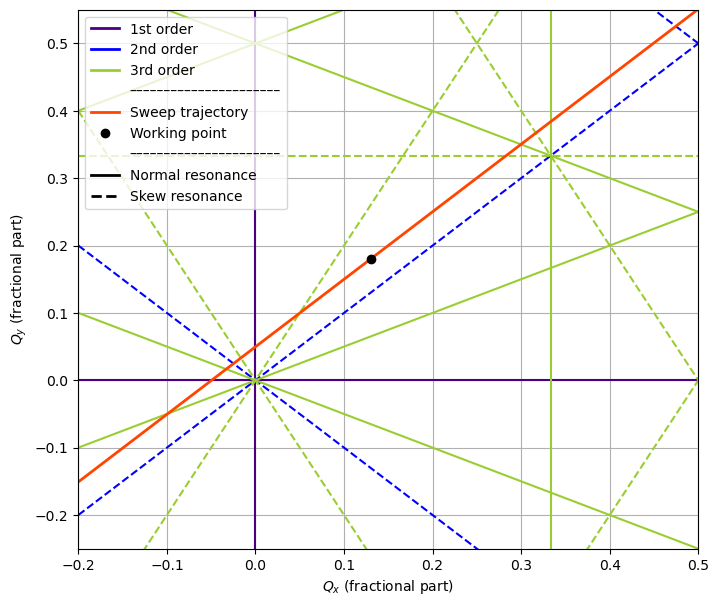

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from math import gcd, floor, ceil

# -----------------------------
# Helpers: p sampling + dedup
# -----------------------------
def legend_divider(text="-"*18):
    # Invisible handle + visible label = looks like a dashed separator row
    return mlines.Line2D([], [], linestyle="none", marker=None, color="none", label=text)

def _gcd3(a, b, c):
    return gcd(gcd(abs(a), abs(b)), abs(c))

def line_key(m, n, p):
    """
    Canonical key for the line m*Qx + n*Qy = p, modulo integer scaling.
    Prevents duplicates like (2,0,0) vs (1,0,0).
    """
    g = _gcd3(m, n, p)
    m1, n1, p1 = m // g, n // g, p // g

    # canonical sign (unique up to global -1)
    if (m1 < 0) or (m1 == 0 and n1 < 0) or (m1 == 0 and n1 == 0 and p1 < 0):
        m1, n1, p1 = -m1, -n1, -p1
    return (m1, n1, p1)

def p_values_in_box(xlim, ylim, m, n):
    """All integer p for which m*x + n*y = p intersects the rectangle."""
    xs = [xlim[0], xlim[1]]
    ys = [ylim[0], ylim[1]]
    vals = [m*x + n*y for x in xs for y in ys]
    pmin = floor(min(vals))
    pmax = ceil(max(vals))
    return range(pmin, pmax + 1)

def primitive_mn(m, n):
    """Reduce (m,n) to primitive gcd(|m|,|n|)=1 with a fixed sign convention."""
    g = gcd(abs(m), abs(n))
    m0, n0 = m // g, n // g
    if (m0 < 0) or (m0 == 0 and n0 < 0):
        m0, n0 = -m0, -n0
    return m0, n0

def mn_possibilities_of_order(order):
    """
    Generate unique primitive (m,n) with |m|+|n| == order.
    This ensures e.g. 2Qx=p is not duplicated with Qx=p.
    """
    out = set()
    for m in range(-order, order + 1):
        for n in range(-order, order + 1):
            if m == 0 and n == 0:
                continue
            m0, n0 = primitive_mn(m, n)
            if abs(m0) + abs(n0) == order:
                out.add((m0, n0))
    return sorted(out)

def plot_mn_family(ax, xlim, ylim, mn_list, color, linestyle, plotted, make_line):
    """For each (m,n), sample p and plot if not already plotted."""
    for (m, n) in mn_list:
        for p in p_values_in_box(xlim, ylim, m, n):
            k = line_key(m, n, p)
            if k in plotted:
                continue
            plotted.add(k)
            make_line(xlim, ylim, m, n, p, ax, color=color, ls=linestyle)

# -----------------------------
# Your inputs / styling
# -----------------------------
colours = {1: 'indigo', 2: 'blue', 3: 'yellowgreen'}
ls      = {'normal' : '-', 'skew' : '--'}

xlim = (-0.2, 0.5)
ylim = (-0.25, 0.55)

# Use EXACTLY the possibilities you provided:
third_order_normal = [(3, 0), (-1, 0), (1, 2), (-1, 2), (-1, 0)]
third_order_skew   = [(0, 3), (0, -1), (2, 1), (-2, 1), (0, 1)]

# Dedup any repeated (m,n) in the lists (e.g. (-1,0) appears twice)
third_order_normal = list(dict.fromkeys(third_order_normal))
third_order_skew   = list(dict.fromkeys(third_order_skew))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
plotted = set()

# 1st + 2nd order: generate (m,n), sample p, dedup plotted lines
for order, type_res in zip((1, 2), ('normal', 'skew')):
    mn_list = mn_possibilities_of_order(order)
    plot_mn_family(ax, xlim, ylim, mn_list, colours[order], ls[type_res], plotted, make_line)

# 3rd order normal + skew: your fixed families, sample p, dedup
plot_mn_family(ax, xlim, ylim, third_order_normal, colours[3], ls['normal'], plotted, make_line)
plot_mn_family(ax, xlim, ylim, third_order_skew,   colours[3], ls['skew'], plotted, make_line)

# Sweep trajectory + working point
qx_gen = np.linspace(xlim[0], xlim[1], 1000)
ax.plot(qx_gen, 20.18/20.13 * (qx_gen - 0.13) + 0.18, color='orangered', lw=2)
ax.scatter(0.13, 0.18, color='k', zorder=5)

# Axes
ax.grid(True)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Legend (upper left)
handles = [
    mlines.Line2D([], [], color=colours[1], ls=ls['normal'], lw=2, label="1st order"),
    mlines.Line2D([], [], color=colours[2], ls=ls['normal'], lw=2, label="2nd order"),
    mlines.Line2D([], [], color=colours[3], ls=ls['normal'], lw=2, label="3rd order"),

    legend_divider("–"*22),

    mlines.Line2D([], [], color="orangered", lw=2, label="Sweep trajectory"),
    mlines.Line2D([], [], color="k", marker="o", ls="None", markersize=6, label="Working point"),
    
    legend_divider("–"*22),
    
    mlines.Line2D([], [], color="k", ls="-", lw=2, label="Normal resonance"),
    mlines.Line2D([], [], color="k", ls="--", lw=2, label="Skew resonance"),
]
ax.legend(handles=handles, loc="upper left", frameon=True)
ax.set_xlabel(r"$Q_x$ (fractional part)")
ax.set_ylabel(r"$Q_y$ (fractional part)")
plt.show()


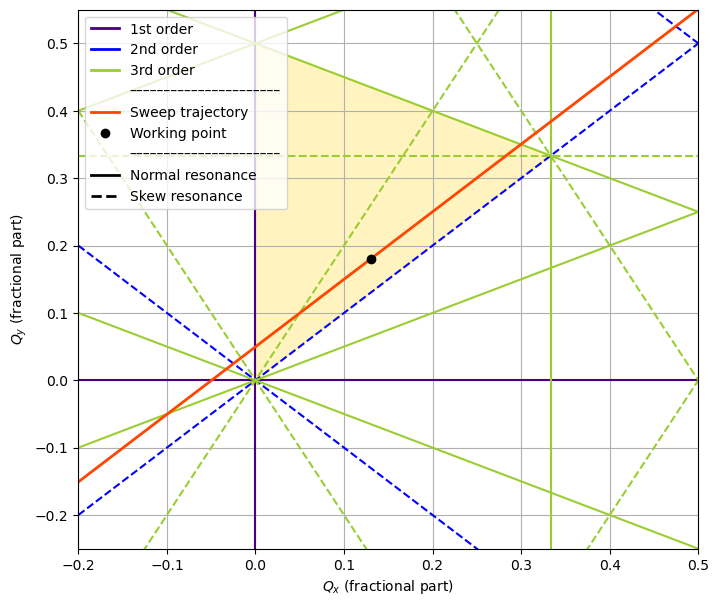

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from math import gcd, floor, ceil

# -----------------------------
# Helpers: p sampling + dedup
# -----------------------------
def legend_divider(text="-"*18):
    # Invisible handle + visible label = looks like a dashed separator row
    return mlines.Line2D([], [], linestyle="none", marker=None, color="none", label=text)

def _gcd3(a, b, c):
    return gcd(gcd(abs(a), abs(b)), abs(c))

def line_key(m, n, p):
    """
    Canonical key for the line m*Qx + n*Qy = p, modulo integer scaling.
    Prevents duplicates like (2,0,0) vs (1,0,0).
    """
    g = _gcd3(m, n, p)
    m1, n1, p1 = m // g, n // g, p // g

    # canonical sign (unique up to global -1)
    if (m1 < 0) or (m1 == 0 and n1 < 0) or (m1 == 0 and n1 == 0 and p1 < 0):
        m1, n1, p1 = -m1, -n1, -p1
    return (m1, n1, p1)

def p_values_in_box(xlim, ylim, m, n):
    """All integer p for which m*x + n*y = p intersects the rectangle."""
    xs = [xlim[0], xlim[1]]
    ys = [ylim[0], ylim[1]]
    vals = [m*x + n*y for x in xs for y in ys]
    pmin = floor(min(vals))
    pmax = ceil(max(vals))
    return range(pmin, pmax + 1)

def primitive_mn(m, n):
    """Reduce (m,n) to primitive gcd(|m|,|n|)=1 with a fixed sign convention."""
    g = gcd(abs(m), abs(n))
    m0, n0 = m // g, n // g
    if (m0 < 0) or (m0 == 0 and n0 < 0):
        m0, n0 = -m0, -n0
    return m0, n0

def mn_possibilities_of_order(order):
    """
    Generate unique primitive (m,n) with |m|+|n| == order.
    This ensures e.g. 2Qx=p is not duplicated with Qx=p.
    """
    out = set()
    for m in range(-order, order + 1):
        for n in range(-order, order + 1):
            if m == 0 and n == 0:
                continue
            m0, n0 = primitive_mn(m, n)
            if abs(m0) + abs(n0) == order:
                out.add((m0, n0))
    return sorted(out)

def plot_mn_family(ax, xlim, ylim, mn_list, color, linestyle, plotted, make_line):
    """For each (m,n), sample p and plot if not already plotted."""
    for (m, n) in mn_list:
        for p in p_values_in_box(xlim, ylim, m, n):
            k = line_key(m, n, p)
            if k in plotted:
                continue
            plotted.add(k)
            make_line(xlim, ylim, m, n, p, ax, color=color, ls=linestyle)

# -----------------------------
# Your inputs / styling
# -----------------------------
colours = {1: 'indigo', 2: 'blue', 3: 'yellowgreen'}
ls      = {'normal' : '-', 'skew' : '--'}

xlim = (-0.2, 0.5)
ylim = (-0.25, 0.55)

# Use EXACTLY the possibilities you provided:
third_order_normal = [(3, 0), (-1, 0), (1, 2), (-1, 2), (-1, 0)]
third_order_skew   = [(0, 3), (0, -1), (2, 1), (-2, 1), (0, 1)]

# Dedup any repeated (m,n) in the lists (e.g. (-1,0) appears twice)
third_order_normal = list(dict.fromkeys(third_order_normal))
third_order_skew   = list(dict.fromkeys(third_order_skew))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
plotted = set()

# 1st + 2nd order: generate (m,n), sample p, dedup plotted lines
for order, type_res in zip((1, 2), ('normal', 'skew')):
    mn_list = mn_possibilities_of_order(order)
    plot_mn_family(ax, xlim, ylim, mn_list, colours[order], ls[type_res], plotted, make_line)

# 3rd order normal + skew: your fixed families, sample p, dedup
plot_mn_family(ax, xlim, ylim, third_order_normal, colours[3], ls['normal'], plotted, make_line)
plot_mn_family(ax, xlim, ylim, third_order_skew,   colours[3], ls['skew'], plotted, make_line)

# Sweep trajectory + working point
qx_gen = np.linspace(xlim[0], xlim[1], 1000)
ax.plot(qx_gen, 20.18/20.13 * (qx_gen - 0.13) + 0.18, color='orangered', lw=2)
ax.scatter(0.13, 0.18, color='k', zorder=5)

# Axes
ax.grid(True)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Legend (upper left)
handles = [
    mlines.Line2D([], [], color=colours[1], ls=ls['normal'], lw=2, label="1st order"),
    mlines.Line2D([], [], color=colours[2], ls=ls['normal'], lw=2, label="2nd order"),
    mlines.Line2D([], [], color=colours[3], ls=ls['normal'], lw=2, label="3rd order"),

    legend_divider("–"*22),

    mlines.Line2D([], [], color="orangered", lw=2, label="Sweep trajectory"),
    mlines.Line2D([], [], color="k", marker="o", ls="None", markersize=6, label="Working point"),
    
    legend_divider("–"*22),
    
    mlines.Line2D([], [], color="k", ls="-", lw=2, label="Normal resonance"),
    mlines.Line2D([], [], color="k", ls="--", lw=2, label="Skew resonance"),
]
tri = np.array([
    [0.0, 0.0],        # (0,0)
    [0.0, 0.5],        # (1,0)
    [1/3, 1/3],        # (1/3, 1/3)
])

# assuming you already have fig, ax
ax.fill(tri[:, 0], tri[:, 1], alpha=0.25, edgecolor='k', linewidth=1.5, zorder=0, color='gold')
ax.legend(handles=handles, loc="upper left", frameon=True)
ax.set_xlabel(r"$Q_x$ (fractional part)")
ax.set_ylabel(r"$Q_y$ (fractional part)")
plt.show()


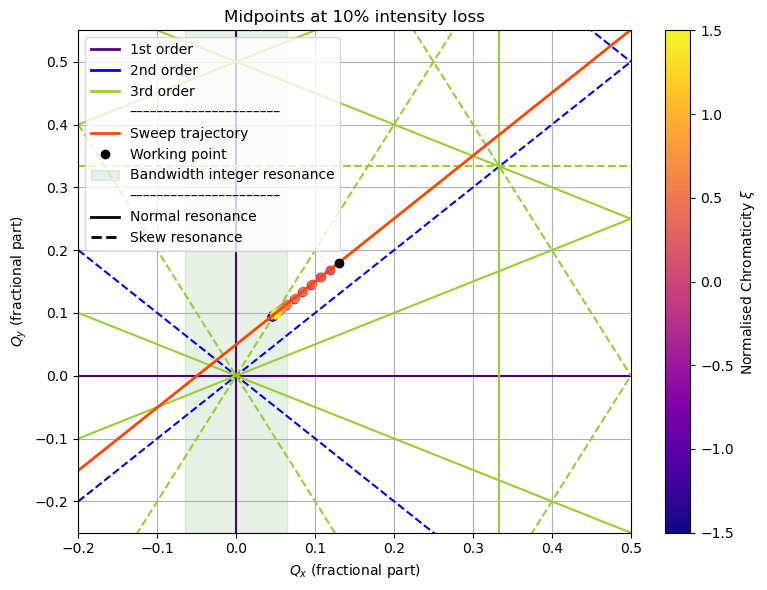

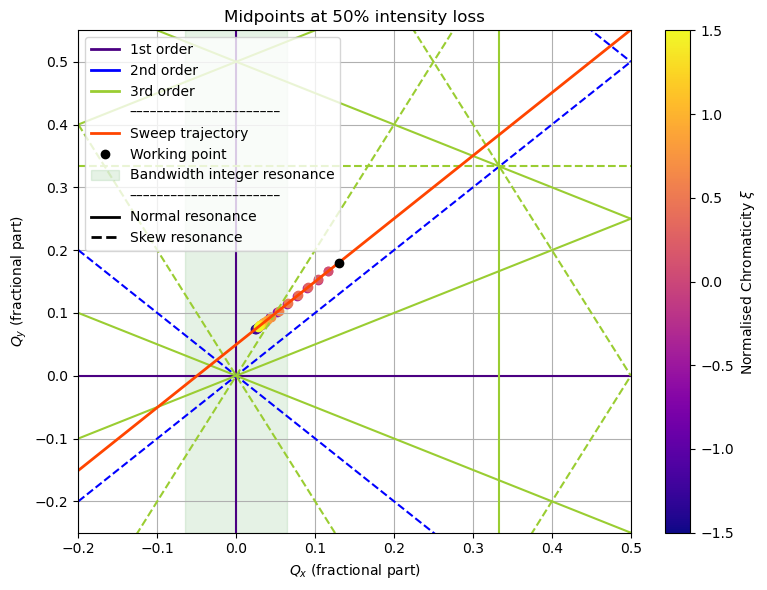

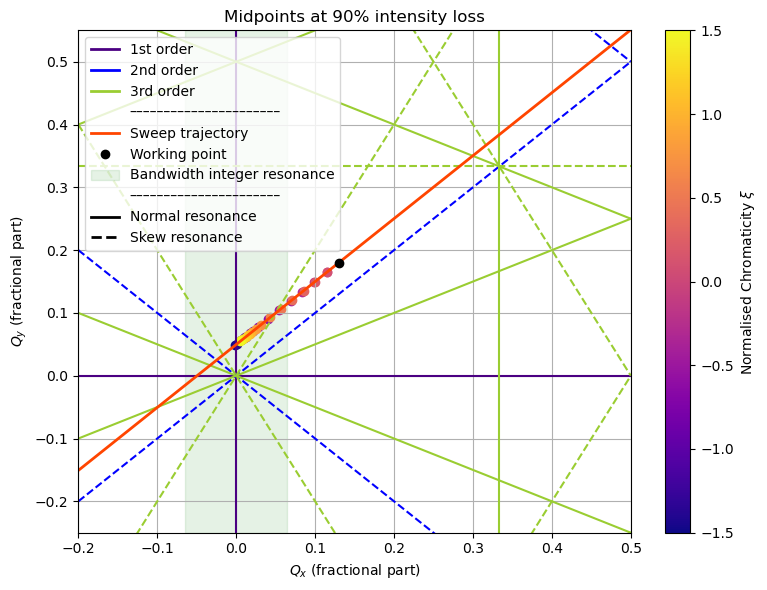

In [40]:
percentiles = [90, 50, 10]
for percentile in percentiles: 
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    cmap = plt.get_cmap('plasma')
    norm = plt.Normalize(vmin=min(tune_diagram_midpoints[percentile].keys()), vmax=max(tune_diagram_midpoints[percentile].keys()))
    plotted = set()

    ax.axvspan(-0.065, 0.065, alpha=0.1, color="green")
    # 1st + 2nd order: generate (m,n), sample p, dedup plotted lines
    for order, type_res in zip((1, 2), ('normal', 'skew')):
        mn_list = mn_possibilities_of_order(order)
        plot_mn_family(ax, xlim, ylim, mn_list, colours[order], ls[type_res], plotted, make_line)

    # 3rd order normal + skew: your fixed families, sample p, dedup
    plot_mn_family(ax, xlim, ylim, third_order_normal, colours[3], ls['normal'], plotted, make_line)
    plot_mn_family(ax, xlim, ylim, third_order_skew,   colours[3], ls['skew'], plotted, make_line)

    # Sweep trajectory + working point
    qx_gen = np.linspace(xlim[0], xlim[1], 1000)
    ax.plot(qx_gen, 20.18/20.13 * (qx_gen - 0.13) + 0.18, color='orangered', lw=2)
    ax.scatter(0.13, 0.18, color='k', zorder=5)

    chromas = sorted(midpoints[percentile]['linear'].keys())
    counter = 0
    for chroma in chromas:
        if tune_diagram_midpoints[percentile][chroma]['DPpos'][0] < 0:
            counter+=1
            ax.scatter(tune_diagram_midpoints[percentile][chroma]['DPpos'][0]+0.13, tune_diagram_midpoints[percentile][chroma]['DPpos'][1]+0.18, color=cmap(norm(chroma)), label=f'Chroma {chroma} DPpos')
        if tune_diagram_midpoints[percentile][chroma]['DPneg'][0] < 0:
            ax.scatter(tune_diagram_midpoints[percentile][chroma]['DPneg'][0]+0.13, tune_diagram_midpoints[percentile][chroma]['DPneg'][1]+0.18, color=cmap(norm(chroma)), label=f'Chroma {chroma} DPneg')
    
    # Axes
    ax.grid(True)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # Legend (upper left)
    handles = [
    mlines.Line2D([], [], color=colours[1], ls=ls['normal'], lw=2, label="1st order"),
    mlines.Line2D([], [], color=colours[2], ls=ls['normal'], lw=2, label="2nd order"),
    mlines.Line2D([], [], color=colours[3], ls=ls['normal'], lw=2, label="3rd order"),

    legend_divider("–"*22),

    mlines.Line2D([], [], color="orangered", lw=2, label="Sweep trajectory"),
    mlines.Line2D([], [], color="k", marker="o", ls="None", markersize=6, label="Working point"),
    mpatches.Patch(color="green", alpha=0.1, label="Bandwidth integer resonance"),
    
    legend_divider("–"*22),
    
    mlines.Line2D([], [], color="k", ls="-", lw=2, label="Normal resonance"),
    mlines.Line2D([], [], color="k", ls="--", lw=2, label="Skew resonance"),
]
    ax.legend(handles=handles, loc="upper left", frameon=True)
    ax.set_xlabel(r"$Q_x$ (fractional part)")
    ax.set_ylabel(r"$Q_y$ (fractional part)")
    ax.set_title(f'Midpoints at {100-percentile}% intensity loss')

    fig.tight_layout()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r'Normalised Chromaticity $\xi$')
    plt.show()


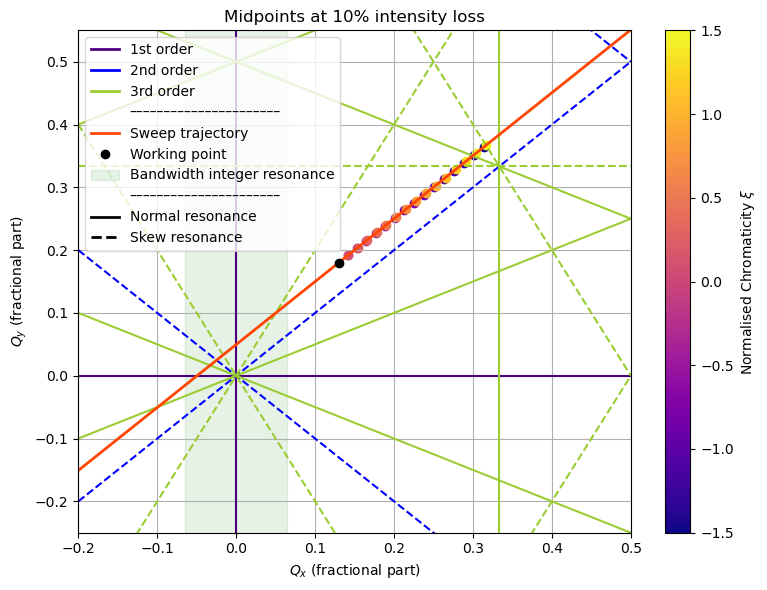

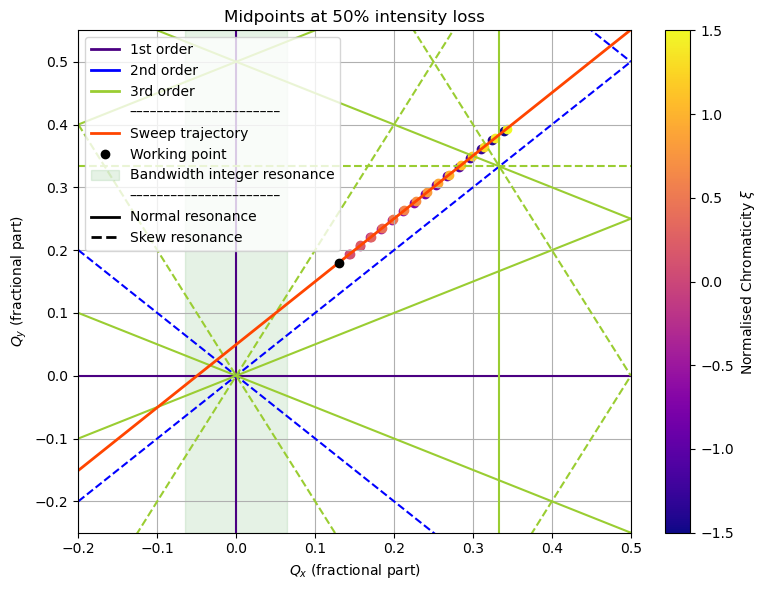

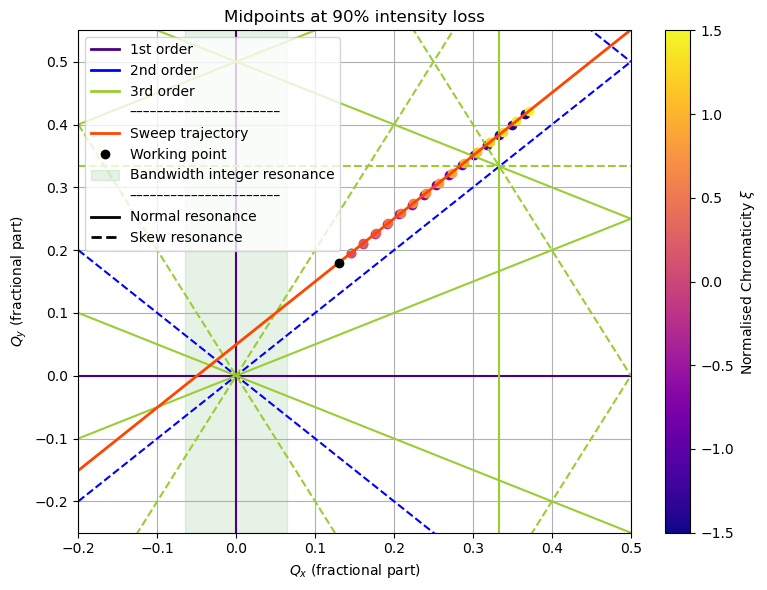

In [41]:
percentiles = [90, 50, 10]
for percentile in percentiles: 
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    cmap = plt.get_cmap('plasma')
    norm = plt.Normalize(vmin=min(tune_diagram_midpoints[percentile].keys()), vmax=max(tune_diagram_midpoints[percentile].keys()))
    plotted = set()

    ax.axvspan(-0.065, 0.065, alpha=0.1, color="green")
    # 1st + 2nd order: generate (m,n), sample p, dedup plotted lines
    for order, type_res in zip((1, 2), ('normal', 'skew')):
        mn_list = mn_possibilities_of_order(order)
        plot_mn_family(ax, xlim, ylim, mn_list, colours[order], ls[type_res], plotted, make_line)

    # 3rd order normal + skew: your fixed families, sample p, dedup
    plot_mn_family(ax, xlim, ylim, third_order_normal, colours[3], ls['normal'], plotted, make_line)
    plot_mn_family(ax, xlim, ylim, third_order_skew,   colours[3], ls['skew'], plotted, make_line)

    # Sweep trajectory + working point
    qx_gen = np.linspace(xlim[0], xlim[1], 1000)
    ax.plot(qx_gen, 20.18/20.13 * (qx_gen - 0.13) + 0.18, color='orangered', lw=2)
    ax.scatter(0.13, 0.18, color='k', zorder=5)

    chromas = sorted(midpoints[percentile]['linear'].keys())
    counter = 0
    for chroma in chromas:
        if tune_diagram_midpoints[percentile][chroma]['DPpos'][0] > 0:
            counter+=1
            ax.scatter(tune_diagram_midpoints[percentile][chroma]['DPpos'][0]+0.13, tune_diagram_midpoints[percentile][chroma]['DPpos'][1]+0.18, color=cmap(norm(chroma)), label=f'Chroma {chroma} DPpos')
        if tune_diagram_midpoints[percentile][chroma]['DPneg'][0] > 0:
            ax.scatter(tune_diagram_midpoints[percentile][chroma]['DPneg'][0]+0.13, tune_diagram_midpoints[percentile][chroma]['DPneg'][1]+0.18, color=cmap(norm(chroma)), label=f'Chroma {chroma} DPneg')
    
    # Axes
    ax.grid(True)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # Legend (upper left)
    handles = [
    mlines.Line2D([], [], color=colours[1], ls=ls['normal'], lw=2, label="1st order"),
    mlines.Line2D([], [], color=colours[2], ls=ls['normal'], lw=2, label="2nd order"),
    mlines.Line2D([], [], color=colours[3], ls=ls['normal'], lw=2, label="3rd order"),

    legend_divider("–"*22),

    mlines.Line2D([], [], color="orangered", lw=2, label="Sweep trajectory"),
    mlines.Line2D([], [], color="k", marker="o", ls="None", markersize=6, label="Working point"),
    mpatches.Patch(color="green", alpha=0.1, label="Bandwidth integer resonance"),
    
    legend_divider("–"*22),
    
    mlines.Line2D([], [], color="k", ls="-", lw=2, label="Normal resonance"),
    mlines.Line2D([], [], color="k", ls="--", lw=2, label="Skew resonance"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=True)
    ax.set_xlabel(r"$Q_x$ (fractional part)")
    ax.set_ylabel(r"$Q_y$ (fractional part)")
    ax.set_title(f'Midpoints at {100-percentile}% intensity loss')

    fig.tight_layout()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r'Normalised Chromaticity $\xi$')
    plt.show()


In [47]:
tune_diagram_midpoints[10][1.5]['DPpos']

(np.float64(0.240919500496484), np.float64(0.2415179095886263))